# Prevendo o tempo de volta na Fórmula 1

**Monza 2024 · regressão linear implementada do zero**

> **Resultado: RMSE teste 0,587 contra 1,299 de baseline (55% de redução).**
>
> Eu previa que esse número fosse otimista: o corte é aleatório, e voltas seguidas do mesmo piloto são quase gêmeas, então embaralhar coloca as duas nos dois lados. Medi com 200 repetições e **o vazamento não apareceu**:
>
> | corte | RMSE | o que mede |
> |---|---|---|
> | aleatório | 0,572 ± 0,028 | interpolação |
> | bloco de stint | 0,593 ± 0,034 | stint inteiro nunca visto |
> | temporal | 0,768 | prever o fim da corrida |
>
> Os dois primeiros são indistinguíveis: a diferença de 0,021 é menor que o desvio de cada um. Faz sentido depois do fato: dentro de um stint o piloto e o composto são constantes, e `lapnumber` e `tyrelife` avançam linearmente, então ter visto a volta vizinha não acrescenta nada que as features já não carreguem. A piora do temporal (0,768) é extrapolação para o fim de corrida, não vazamento.
>
> **Uma ressalva que precisa vir junto:** 0,587 ≈ 0,59, e na Fórmula 1 0,59 seg por volta é aproximadamente a diferença entre carros de meio de grid. Ou seja, o erro do modelo tem a mesma ordem de grandeza do efeito que eu quero medir, e é por isso que companheiros de equipe saem indistinguíveis.

---

### A pergunta

Ritmo puro do conjunto piloto-carro, descontando combustível, pneu e composto. E porque eu escolhi essa alternativa e não a alternativa de prever o tempo aconteça o que acontecer.

### Os dados

Monza 2024, FastF1.

```
26.604 voltas (temporada)  →  1.008 (Monza)  →  922 (após filtros)
```

**Porque Monza?**

Corrida sem safety car. E vitória da Ferrari, um grande fã.

### O que foi removido no filtro e porque?

Box, volta 1, piloto que abandonou.

Voltas de entradas e saída do box são voltas muito mais lentas, justamente pela entrada e saída do box. Volta 1, por os pilotos largarem parados a velocidade média é reduzida e aumenta o tempo total delta t do trajeto. Piloto (yuki tsunoda) que abandonou foi retirado pelo pouco número de voltas na corrida.

### As features e porque só essas?

Descartamos o tempo por setores e a velocidade pelo vazamento ao modelo. O recorte clima, evento e trackstatus eram constantes, não tinha porque deixar. Colinearidade em team com driver e tracktemp com lapnumber, por isso foi tirado também. E o caso do tyrelife, correlação marginal zero e o coeficiente parcial forte, por isso deixamos.

### O modelo

Fiz a regressão linear pela equação normal, implementada do zero:

$$w = (X^{T}X)^{-1} X^{T} y$$

No final comparei com a biblioteca sklearn e bateu em 12 casas, a prova de que foi implementada corretamente.

### Resultados

O RMSE foi de 1,24 → 0,82 → 0,53.

| features | RMSE validação |
|---|---|
| chutar a média (baseline) | 1,24 |
| `lapnumber` + `tyrelife` | 0,82 |
| + `driver` + `compound` | 0,53 |
| **teste (uma única vez)** | **0,587** |

No final o teste foi de 0,587, 55% de redução, por maior dispersão presente no conjunto de teste.

**O que os dois coeficientes principais dizem:**

A cada volta o carro fica −0,065 mais rápido, isso é o tanque do carro esvaziando, carro fica leve e anda mais rápido. E a cada volta do pneu o carro fica +0,062 mais lento, isso é a degradação.

### Limitações

Apenas uma corrida, quantidade de informações não suficientes por tudo que eu queria fazer, como a comparação entre Norris-Piastri (companheiros de equipe).

A degradação por composto não é respondível, a estratégia e vida útil dos pneus impossibilitou (truncamento por estratégia).

## Tabela de decisões

Cada linha é uma escolha que mudou o resultado. Coloquei a alternativa que descartei, o motivo e o número que sustenta, pra deixar claro que nada foi por acaso. Os `±` são margem de 95%, não erro-padrão.

| Decisão | Alternativa descartada | Por quê | Número |
|---|---|---|---|
| Modelar o **ritmo puro do conjunto piloto-carro** | Prever o tempo aconteça o que acontecer | Descontando combustível, pneu e composto | 0,587 contra baseline 1,299 (55%) |
| Descartar **tempo por setores e velocidade** | Usar como features | Vazamento: são pedaço do próprio tempo de volta, então o modelo estaria lendo a resposta | soma dos setores = tempo da volta |
| **Manter `tyrelife`** | Descartar pela correlação marginal quase nula | Antes quase descartei pela correlação marginal de −0,034, era quase zero pq o pneu importa tanto como o combustível nessa pista de Monza | se eu descartasse era 0,062 s/volta, em 20 voltas de stint mais de um segundo de degradação invisível |
| Manter **`lapnumber` e `tyrelife` juntas** | Uma só, pela correlação de 1,0 dentro do stint | Dentro de um stint esses números avançam juntos. O modelo separou os dois pelas descontinuidades: as paradas são a fonte de identificação | corr 1,000 dentro do stint, 0,560 na corrida toda |
| Ler os coeficientes como **física**, não como ajuste | Reportar só o RMSE | A cada volta o carro fica −0,065 mais rápido, é o tanque esvaziando. E a cada volta do pneu fica +0,062 mais lento, é a degradação | soma −0,0028 ≈ zero, é o que explica a correlação marginal |
| Reportar **intervalo** junto do ranking | Só a ordem dos coeficientes | Se eu só ordenasse os coeficientes ia parecer que tenho uma precisão que eu não tenho | `nor` +0,103 ± 0,292 e `pia` −0,098 ± 0,302, indistinguíveis. `zho` +2,354, esse sim separado |
| Testar **`tyrelife × medium`** e aceitar o resultado negativo | Anunciar taxas diferentes por composto | Previ que o médio degradaria mais rápido, o resultado me contradisse, mas o intervalo cruza o zero, então os dados não sustentam a diferença | $w_P$ −0,0205 ± 0,0110; RMSE 0,5313 → 0,5308, não pagou o grau de liberdade |
| Corte de validação **aleatório** | Corte por bloco de stint | Medi o quanto o aleatório inflou e deu 4%. O bloco cobra caro demais: tira as paradas do treino, que são o que separa combustível de degradação | aleatório 0,5716 ± 0,0276, bloco 0,5931 ± 0,0337 (200 repetições), distribuições se sobrepõem |
| **Equação normal do zero** | `sklearn` direto | Pra ver como realmente funciona, que não é mágica, e poder criar o mesmo tipo de mágica de forma autoral | diferença de 8,2e−13 nos pesos contra o sklearn |

**Outras decisões**, documentadas ao longo do notebook: escolha das referências (`lec` e `hard`), descarte de `team`, `tracktemp`, `airtemp`, `lapstartdate` e `freshtyre` por colinearidade, `compound_soft` marcado como não estimável (n=1), ausência de termo quadrático em `tyrelife`, e a heterocedasticidade aceita e registrada.

### O fenomeno

Nao e um grafico de diagnostico, e o grafico que mostra do que o projeto trata. A celula abaixo e autonoma: recarrega o parquet e refaz os filtros, porque fica antes do resto do notebook.

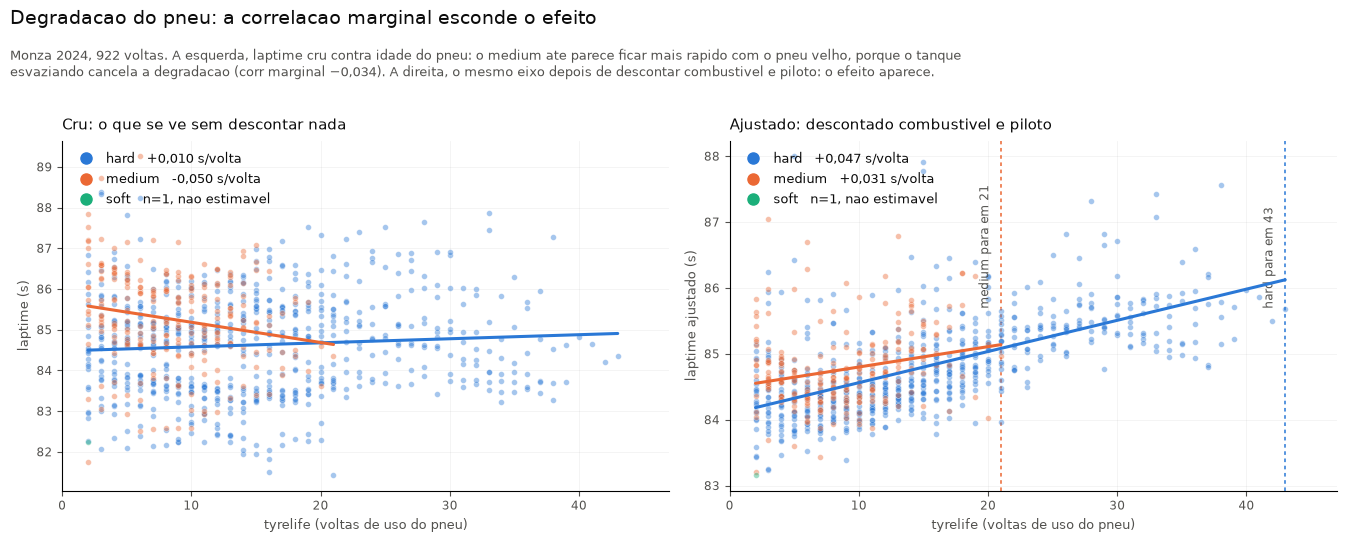

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


_df = pd.read_parquet('voltas_f1.parquet')
_df.columns = _df.columns.str.lower().str.replace(' ', '_')
for _c in [c for c in _df.columns if pd.api.types.is_string_dtype(_df[c])]:
    _df[_c] = _df[_c].str.lower().str.replace(' ', '_')

_m = _df[_df.evento == 'italian_grand_prix']
_m = _m[_m.pitintime.isna() & _m.pitouttime.isna() & (_m.lapnumber != 1.0)]
_m = _m[_m.driver != 'tsu'].reset_index(drop=True)

_D = pd.get_dummies(_m.driver, prefix='d', drop_first=True).astype(float)
_C = pd.get_dummies(_m.compound, prefix='c', drop_first=True).astype(float)
_X = np.column_stack([np.ones(len(_m)), _m.lapnumber, _m.tyrelife, _D.values, _C.values])
_w = np.linalg.lstsq(_X, _m.laptime.values, rcond=None)[0]

_fora = _w[1] * _m.lapnumber.values + _D.values @ _w[3:3 + _D.shape[1]]
_m['ajustado'] = _m.laptime.values - _fora + _fora.mean()

COR = {'hard': '#2a78d6', 'medium': '#eb6834', 'soft': '#1baf7a'}
TINTA, TINTA2 = '#0b0b0b', '#52514e'

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharex=True)

for ax, col, titulo in [
    (axes[0], 'laptime',  'Cru: o que se ve sem descontar nada'),
    (axes[1], 'ajustado', 'Ajustado: descontado combustivel e piloto'),
]:
    marcas = []
    for comp in ['hard', 'medium', 'soft']:
        g = _m[_m.compound == comp]
        ax.scatter(g.tyrelife, g[col], s=17, color=COR[comp], alpha=.42,
                   linewidths=.4, edgecolors='white', zorder=2)

        if len(g) > 2:                                # reta so onde ha dado que a sustente
            b = np.polyfit(g.tyrelife, g[col], 1)
            xs = np.array([g.tyrelife.min(), g.tyrelife.max()])
            ax.plot(xs, np.polyval(b, xs), color=COR[comp], lw=2.2, zorder=4,
                    solid_capstyle='round')
            rotulo = f'{comp}   {b[0]:+.3f} s/volta'.replace('.', ',')
        else:
            rotulo = f'{comp}   n={len(g)}, nao estimavel'

        marcas.append(Line2D([], [], marker='o', ls='', ms=8, color=COR[comp], label=rotulo))

    leg = ax.legend(handles=marcas, frameon=False, fontsize=9, loc='upper left',
                    handletextpad=.6, labelspacing=.5)
    for t in leg.get_texts():                          # texto em tinta neutra, cor so na marca
        t.set_color(TINTA)

    ax.set_title(titulo, fontsize=11, color=TINTA, loc='left', pad=8)
    ax.set_xlabel('tyrelife (voltas de uso do pneu)', fontsize=9, color=TINTA2)
    ax.grid(alpha=.16, lw=.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TINTA2, labelsize=8.5)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

axes[0].set_ylabel('laptime (s)', fontsize=9, color=TINTA2)
axes[1].set_ylabel('laptime ajustado (s)', fontsize=9, color=TINTA2)
axes[0].set_xlim(0, 47)

for comp in ['medium', 'hard']:
    xm = _m[_m.compound == comp].tyrelife.max()
    axes[1].axvline(xm, color=COR[comp], ls=(0, (2, 2)), lw=1.3, alpha=.85, zorder=1)
    axes[1].annotate(f'{comp} para em {xm:.0f}', (xm, .52), xycoords=('data', 'axes fraction'),
                     xytext=(-7, 0), textcoords='offset points', ha='right', va='bottom',
                     rotation=90, fontsize=8.5, color=TINTA2)

fig.suptitle('Degradacao do pneu: a correlacao marginal esconde o efeito',
             fontsize=13.5, color=TINTA, x=.006, ha='left', y=.995)
fig.text(.006, .925,
         'Monza 2024, 922 voltas. A esquerda, laptime cru contra idade do pneu: o medium ate parece ficar mais rapido '
         'com o pneu velho, porque o tanque\nesvaziando cancela a degradacao (corr marginal −0,034). A direita, o mesmo '
         'eixo depois de descontar combustivel e piloto: o efeito aparece.',
         fontsize=9, color=TINTA2, va='top')
fig.tight_layout(rect=[0, 0, 1, .885])
plt.show()

---

# Começo do projeto

Daqui pra baixo é o desenvolvimento na ordem em que aconteceu: carregar os dados, limpar, filtrar, escolher as features, derivar a regressão e avaliar. Tudo o que está acima foi escrito no fim, olhando pra trás.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
import fastf1

In [3]:
fastf1.Cache.enable_cache('./f1_cache')

In [4]:
df = pd.read_parquet('voltas_f1.parquet')
df.shape

(26604, 34)

In [5]:
df.head()

,Ano,Rodada,Evento,Sessao,Driver,DriverNumber,Team,LapNumber,Stint,LapTime,...,PitInTime,PitOutTime,LapStartDate,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection
0,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,1.0,1.0,97.284,...,NaN,NaN,2024-03-02 15:03:42.342,18.2,23.8,49.0,1017.2,False,1.5,58
1,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,2.0,1.0,96.296,...,NaN,NaN,2024-03-02 15:05:19.920,18.3,23.8,49.0,1017.0,False,1.1,33
2,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,3.0,1.0,96.753,...,NaN,NaN,2024-03-02 15:06:56.216,18.3,23.8,49.0,1017.1,False,1.5,89
3,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,4.0,1.0,96.647,...,NaN,NaN,2024-03-02 15:08:32.969,18.3,23.7,49.0,1017.0,False,0.9,24
4,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,5.0,1.0,97.173,...,NaN,NaN,2024-03-02 15:10:09.616,18.3,23.5,50.0,1017.1,False,1.5,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26604 entries, 0 to 26603
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Ano            26604 non-null  int64         
 1   Rodada         26604 non-null  int64         
 2   Evento         26604 non-null  object        
 3   Sessao         26604 non-null  object        
 4   Driver         26604 non-null  object        
 5   DriverNumber   26604 non-null  object        
 6   Team           26604 non-null  object        
 7   LapNumber      26604 non-null  float64       
 8   Stint          26604 non-null  float64       
 9   LapTime        26381 non-null  float64       
 10  Sector1Time    26066 non-null  float64       
 11  Sector2Time    26574 non-null  float64       
 12  Sector3Time    26553 non-null  float64       
 13  SpeedI1        26578 non-null  float64       
 14  SpeedI2        26578 non-null  float64       
 15  SpeedFL        2573

In [7]:
df.isnull().sum()

Ano                  0
Rodada               0
Evento               0
Sessao               0
Driver               0
DriverNumber         0
Team                 0
LapNumber            0
Stint                0
LapTime            223
Sector1Time        538
Sector2Time         30
Sector3Time         51
SpeedI1             26
SpeedI2             26
SpeedFL            874
SpeedST             32
Compound             0
TyreLife             0
FreshTyre            0
TrackStatus          0
Position            26
IsAccurate           0
Deleted              0
PitInTime        25755
PitOutTime       25764
LapStartDate         0
AirTemp              0
TrackTemp            0
Humidity             0
Pressure             0
Rainfall             0
WindSpeed            0
WindDirection        0
dtype: int64

In [8]:
df.columns = df.columns.str.lower().str.replace(' ', '_') #Limpeza de dados

In [9]:
df.head()

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
0,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,1.0,1.0,97.284,...,NaN,NaN,2024-03-02 15:03:42.342,18.2,23.8,49.0,1017.2,False,1.5,58
1,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,2.0,1.0,96.296,...,NaN,NaN,2024-03-02 15:05:19.920,18.3,23.8,49.0,1017.0,False,1.1,33
2,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,3.0,1.0,96.753,...,NaN,NaN,2024-03-02 15:06:56.216,18.3,23.8,49.0,1017.1,False,1.5,89
3,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,4.0,1.0,96.647,...,NaN,NaN,2024-03-02 15:08:32.969,18.3,23.7,49.0,1017.0,False,0.9,24
4,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,5.0,1.0,97.173,...,NaN,NaN,2024-03-02 15:10:09.616,18.3,23.5,50.0,1017.1,False,1.5,40


In [10]:
strings = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])] #Limpeza de dados

In [11]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_') #Limpeza de dados

In [12]:
df.head()

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
0,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,1.0,1.0,97.284,...,NaN,NaN,2024-03-02 15:03:42.342,18.2,23.8,49.0,1017.2,False,1.5,58
1,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,2.0,1.0,96.296,...,NaN,NaN,2024-03-02 15:05:19.920,18.3,23.8,49.0,1017.0,False,1.1,33
2,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,3.0,1.0,96.753,...,NaN,NaN,2024-03-02 15:06:56.216,18.3,23.8,49.0,1017.1,False,1.5,89
3,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,4.0,1.0,96.647,...,NaN,NaN,2024-03-02 15:08:32.969,18.3,23.7,49.0,1017.0,False,0.9,24
4,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,5.0,1.0,97.173,...,NaN,NaN,2024-03-02 15:10:09.616,18.3,23.5,50.0,1017.1,False,1.5,40


In [13]:
df.evento.unique()

array(['bahrain_grand_prix', 'saudi_arabian_grand_prix',
       'australian_grand_prix', 'japanese_grand_prix',
       'chinese_grand_prix', 'miami_grand_prix',
       'emilia_romagna_grand_prix', 'monaco_grand_prix',
       'canadian_grand_prix', 'spanish_grand_prix', 'austrian_grand_prix',
       'british_grand_prix', 'hungarian_grand_prix', 'belgian_grand_prix',
       'dutch_grand_prix', 'italian_grand_prix', 'azerbaijan_grand_prix',
       'singapore_grand_prix', 'united_states_grand_prix',
       'mexico_city_grand_prix', 'são_paulo_grand_prix',
       'las_vegas_grand_prix', 'qatar_grand_prix', 'abu_dhabi_grand_prix'],
      dtype=object)

In [14]:
df_monza = df[df['evento'] == 'italian_grand_prix'] #Filtro para apenas a corrida de Monza

Monza foi escolhido, pois não houve safety car na corrida afetando os tempos das voltas

Além disso vitória da ferrari, leclerc ganhou (ainda confio no título mundial).

In [15]:
df_monza.head() 

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
17122,2024,16,italian_grand_prix,r,lec,16,ferrari,1.0,1.0,88.179,...,NaN,NaN,2024-09-01 13:03:34.413,33.8,51.3,32.0,993.2,False,1.9,191
17123,2024,16,italian_grand_prix,r,lec,16,ferrari,2.0,1.0,85.396,...,NaN,NaN,2024-09-01 13:05:02.850,33.9,50.5,31.0,993.2,False,1.4,218
17124,2024,16,italian_grand_prix,r,lec,16,ferrari,3.0,1.0,85.179,...,NaN,NaN,2024-09-01 13:06:28.246,33.7,50.6,30.0,993.3,False,2.3,185
17125,2024,16,italian_grand_prix,r,lec,16,ferrari,4.0,1.0,84.810,...,NaN,NaN,2024-09-01 13:07:53.425,33.7,50.6,31.0,993.2,False,1.9,201
17126,2024,16,italian_grand_prix,r,lec,16,ferrari,5.0,1.0,84.603,...,NaN,NaN,2024-09-01 13:09:18.235,33.7,50.6,31.0,993.2,False,1.8,194


In [16]:
df_monza = df_monza.reset_index(drop = True)

In [17]:
df_monza['driver'].value_counts() #Contagem de voltas por piloto

driver
lec    53
pia    53
nor    53
sai    53
ham    53
ver    53
rus    53
per    53
alb    53
mag    53
alo    53
col    53
ric    53
oco    52
gas    52
bot    52
hul    52
zho    52
str    52
tsu     7
Name: count, dtype: int64

In [18]:
df_monza.groupby(['driver', 'stint'])['lapnumber'].agg(['min', 'max'])

min   max
driver stint            
alb    1.0     1.0  17.0
       2.0    18.0  53.0
alo    1.0     1.0  12.0
       2.0    13.0  35.0
       3.0    36.0  53.0
bot    1.0     1.0  33.0
       2.0    34.0  52.0
col    1.0     1.0  16.0
       2.0    17.0  53.0
gas    1.0     1.0  10.0
       2.0    11.0  30.0
       3.0    31.0  52.0
ham    1.0     1.0  15.0
       2.0    16.0  37.0
       3.0    38.0  53.0
hul    1.0     1.0   5.0
       2.0     6.0  32.0
       3.0    33.0  52.0
lec    1.0     1.0  15.0
       2.0    16.0  53.0
mag    1.0     1.0  14.0
       2.0    15.0  53.0
nor    1.0     1.0  14.0
       2.0    15.0  32.0
       3.0    33.0  53.0
oco    1.0     1.0  31.0
       2.0    32.0  52.0
per    1.0     1.0  23.0
       2.0    24.0  35.0
       3.0    36.0  53.0
pia    1.0     1.0  16.0
       2.0    17.0  38.0
       3.0    39.0  53.0
ric    1.0     1.0  11.0
       2.0    12.0  53.0
rus    1.0     1.0  11.0
       2.0    12.0  33.0
       3.0    34.0  53.0
sai    1.0     1.0  19.0
       2.0    20.0  53.0
str    1.0     1.0  19.0
       2.0    20.0  36.0
       3.0    37.0  50.0
       4.0    51.0  52.0
tsu    1.0     1.0   7.0
ver    1.0     1.0  22.0
       2.0    23.0  41.0
       3.0    42.0  53.0
zho    1.0     1.0  15.0
       2.0    16.0  52.0

In [19]:
mask = (
    df_monza['pitintime'].isna()
    & df_monza['pitouttime'].isna()
    & (df_monza['lapnumber'] != 1.0)
)

df_clean_monza = df_monza[mask] #Removendo voltas de entrada e saída do box, além da primeira volta(perda de tempo na largada)

In [20]:
df_clean_monza.head()

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
1,2024,16,italian_grand_prix,r,lec,16,ferrari,2.0,1.0,85.396,...,NaN,NaN,2024-09-01 13:05:02.850,33.9,50.5,31.0,993.2,False,1.4,218
2,2024,16,italian_grand_prix,r,lec,16,ferrari,3.0,1.0,85.179,...,NaN,NaN,2024-09-01 13:06:28.246,33.7,50.6,30.0,993.3,False,2.3,185
3,2024,16,italian_grand_prix,r,lec,16,ferrari,4.0,1.0,84.810,...,NaN,NaN,2024-09-01 13:07:53.425,33.7,50.6,31.0,993.2,False,1.9,201
4,2024,16,italian_grand_prix,r,lec,16,ferrari,5.0,1.0,84.603,...,NaN,NaN,2024-09-01 13:09:18.235,33.7,50.6,31.0,993.2,False,1.8,194
5,2024,16,italian_grand_prix,r,lec,16,ferrari,6.0,1.0,84.663,...,NaN,NaN,2024-09-01 13:10:42.838,33.5,50.2,31.0,993.1,False,2.0,192


In [21]:
df_clean_monza['trackstatus'].value_counts()

trackstatus
1    927
Name: count, dtype: int64

In [22]:
df_monza['trackstatus'].astype(str).str.contains('4', na=False).sum() #Vendo se houve safety car na corrida

np.int64(0)

In [23]:
df_clean_monza.nunique() #Vendo quais colunas tem '1', quer dizer que não mudaram em lugar algum e podemos remover

ano                1
rodada             1
evento             1
sessao             1
driver            20
drivernumber      20
team              10
lapnumber         52
stint              4
laptime          836
sector1time      581
sector2time      736
sector3time      734
speedi1           36
speedi2           44
speedfl           19
speedst           58
compound           3
tyrelife          42
freshtyre          2
trackstatus        1
position          20
isaccurate         1
deleted            2
pitintime          0
pitouttime         0
lapstartdate     927
airtemp           17
tracktemp         42
humidity           4
pressure           7
rainfall           1
windspeed         17
winddirection     35
dtype: int64

<Axes: xlabel='laptime', ylabel='Count'>

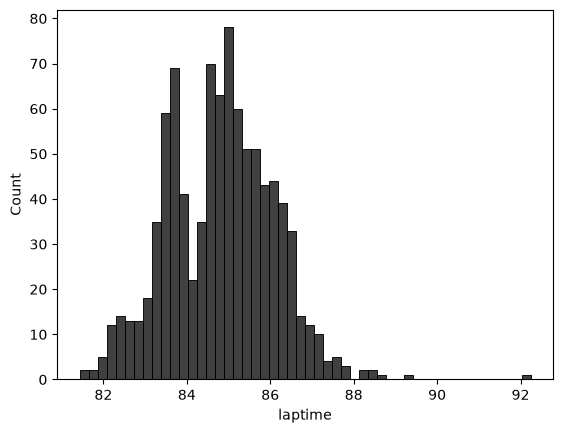

In [24]:
sns.histplot(df_clean_monza.laptime, bins = 50, color = 'black') #Gráfico de tempos de volta

In [25]:
df_clean_monza = df_clean_monza.drop(columns=[
    'ano', 'rodada', 'evento', 'sessao',
    'trackstatus', 'isaccurate', 'rainfall'
])

In [26]:
df_clean_monza.head()

,driver,drivernumber,team,lapnumber,stint,laptime,sector1time,sector2time,sector3time,speedi1,...,deleted,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,windspeed,winddirection
1,lec,16,ferrari,2.0,1.0,85.396,27.707,29.265,28.424,315.0,...,False,NaN,NaN,2024-09-01 13:05:02.850,33.9,50.5,31.0,993.2,1.4,218
2,lec,16,ferrari,3.0,1.0,85.179,27.679,29.001,28.499,313.0,...,False,NaN,NaN,2024-09-01 13:06:28.246,33.7,50.6,30.0,993.3,2.3,185
3,lec,16,ferrari,4.0,1.0,84.810,27.653,28.883,28.274,314.0,...,False,NaN,NaN,2024-09-01 13:07:53.425,33.7,50.6,31.0,993.2,1.9,201
4,lec,16,ferrari,5.0,1.0,84.603,27.630,28.790,28.183,313.0,...,False,NaN,NaN,2024-09-01 13:09:18.235,33.7,50.6,31.0,993.2,1.8,194
5,lec,16,ferrari,6.0,1.0,84.663,27.596,28.945,28.122,315.0,...,False,NaN,NaN,2024-09-01 13:10:42.838,33.5,50.2,31.0,993.1,2.0,192


In [27]:
df_clean_monza.columns

Index(['driver', 'drivernumber', 'team', 'lapnumber', 'stint', 'laptime',
       'sector1time', 'sector2time', 'sector3time', 'speedi1', 'speedi2',
       'speedfl', 'speedst', 'compound', 'tyrelife', 'freshtyre', 'position',
       'deleted', 'pitintime', 'pitouttime', 'lapstartdate', 'airtemp',
       'tracktemp', 'humidity', 'pressure', 'windspeed', 'winddirection'],
      dtype='object')

In [28]:
df_clean_monza = df_clean_monza[df_clean_monza.driver != 'tsu'] #Retirando tsunoda, abandonou com 7 voltas por bater no hulkenberg

<Axes: xlabel='laptime', ylabel='Count'>

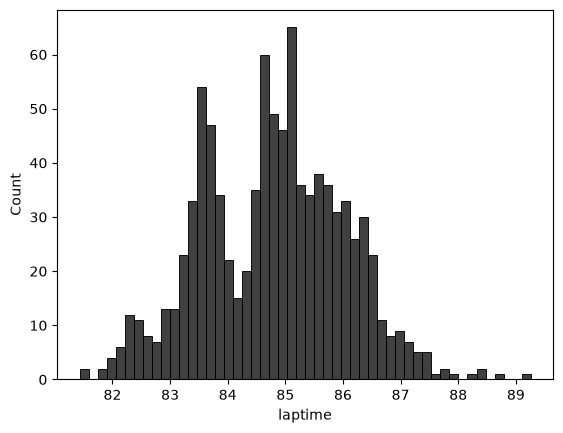

In [29]:
sns.histplot(df_clean_monza.laptime, bins = 50, color = 'black')

In [30]:
df_clean_monza.describe() #Analisando features interessantes para uso

,lapnumber,stint,laptime,sector1time,sector2time,sector3time,speedi1,speedi2,speedfl,speedst,...,position,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,windspeed,winddirection
count,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,...,922.000000,0.0,0.0,922,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000
mean,27.535792,1.877440,84.788775,27.620282,29.005137,28.163357,314.099783,319.199566,312.383948,325.019523,...,9.918655,NaN,NaN,2024-09-01 13:41:47.034820096,32.752061,46.387419,31.532538,992.983406,1.574946,192.486985
min,2.000000,1.000000,81.432000,26.877000,27.439000,26.804000,225.000000,213.000000,294.000000,279.000000,...,1.000000,NaN,NaN,2024-09-01 13:05:02.294000,32.200000,43.600000,30.000000,992.700000,0.600000,0.000000
25%,14.000000,1.000000,83.762750,27.432000,28.590250,27.757000,312.000000,315.000000,311.000000,320.000000,...,5.000000,NaN,NaN,2024-09-01 13:22:43.929499904,32.500000,44.900000,31.000000,992.900000,1.300000,188.000000
50%,28.000000,2.000000,84.852500,27.592000,29.003000,28.189000,314.000000,318.000000,312.000000,323.000000,...,10.000000,NaN,NaN,2024-09-01 13:41:59.932499968,32.600000,45.800000,32.000000,993.000000,1.600000,196.000000
75%,41.000000,2.000000,85.674750,27.753000,29.379750,28.513750,316.000000,322.000000,314.000000,328.000000,...,15.000000,NaN,NaN,2024-09-01 14:01:00.957000192,32.900000,47.600000,32.000000,993.000000,1.800000,201.000000
max,53.000000,4.000000,89.256000,29.201000,31.159000,30.350000,335.000000,343.000000,322.000000,357.000000,...,20.000000,NaN,NaN,2024-09-01 14:18:12.978000,33.900000,50.600000,33.000000,993.300000,2.400000,239.000000
std,15.116030,0.687369,1.239248,0.282505,0.553532,0.504763,5.459039,8.273243,2.580744,8.331855,...,5.480882,NaN,NaN,NaN,0.434956,1.996891,0.663557,0.112112,0.369569,27.738118


## Framework de validação

In [32]:
n = len(df_clean_monza)

n_val = int(len(df_clean_monza) * 0.2)
n_test = int(len(df_clean_monza) * 0.2)
n_train = n - n_val - n_test

n

922

In [33]:
n_val, n_test, n_train

(184, 184, 554)

In [34]:
idx = np.arange(n)

In [35]:
np.random.seed(2)
np.random.shuffle(idx) #aleatório 60/20/20, deixando obrigatório, porque as linhas são ordenadas por piloto

In [36]:
df_train = df_clean_monza.iloc[idx[:n_train]]
df_val = df_clean_monza.iloc[idx[n_train:n_train + n_val]]
df_test = df_clean_monza.iloc[idx[n_train + n_val:]]

In [37]:
df_train.head()

,driver,drivernumber,team,lapnumber,stint,laptime,sector1time,sector2time,sector3time,speedi1,...,deleted,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,windspeed,winddirection
333,rus,63,mercedes,16.0,2.0,84.692,27.635,28.894,28.163,315.0,...,False,NaN,NaN,2024-09-01 13:25:33.414,32.8,47.8,30.0,993.1,1.9,195
420,per,11,red_bull_racing,50.0,3.0,83.390,27.408,28.351,27.631,312.0,...,False,NaN,NaN,2024-09-01 14:13:34.159,32.3,44.1,32.0,992.9,1.6,196
861,hul,27,haas_f1_team,17.0,2.0,86.119,28.068,29.532,28.519,312.0,...,False,NaN,NaN,2024-09-01 13:27:15.566,32.9,47.2,31.0,993.0,1.7,195
252,ham,44,mercedes,41.0,3.0,82.927,27.270,28.351,27.306,312.0,...,False,NaN,NaN,2024-09-01 14:00:43.850,32.5,44.7,32.0,992.9,1.6,201
592,col,43,williams,10.0,1.0,86.289,27.760,29.706,28.823,317.0,...,False,NaN,NaN,2024-09-01 13:16:44.248,33.3,48.6,31.0,993.0,1.8,196


In [38]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True) #Matriz X de características

In [39]:
y_train = df_train.laptime.values
y_test = df_test.laptime.values
y_val = df_val.laptime.values #Alvos

In [40]:
del df_train['laptime']
del df_val['laptime']
del df_test['laptime'] #Removendo variável alvo

## Regressão linear

$x_i$ são as características do carro, clima, piloto e $y_i$ é o tempo de volta:

$$g(x_i) \approx y_i$$

Temos que ter uma função que receba todas essas características e produza algo próximo do tempo de volta do piloto.

$$g(x_i) = w_0 + (w_1 x_{i1}) + (w_2 x_{i2}) + (w_3 x_{i3})$$

$w_0$ é a previsão sem saber nada sobre as características, $w_1 x_{i1}$ = características, $w_2 x_{i2}$ = características.

Ou seja...

$$g(x_i) = w_0 + \sum_j (w_j x_{ij})$$

previsão sem saber nada (viés) + o somatório das características $\times$ peso.

Assumindo que $x_{i0} = 1$:

$$g(x_i) = \sum_j w_j x_{ij}$$

Generalizando para a forma vetorial, devemos transpor o vetor de características $x_i$ e a soma vira um produto escalar:

$$g(x_i) = w_0 + x_i^{T} w$$

$$w = [w_0, w_1, w_2, w_3, \dots, w_n] \qquad x_i = [x_{i0} = 1,\, x_{i1},\, x_{i2},\, \dots,\, x_{in}]$$

$$w^{T} x_i = x_i^{T} w = w_0 + \dots$$

## Forma matricial

$X$ é matriz de características, sendo uma linha para cada info da volta do piloto-carro, e a previsão sai com uma multiplicação matriz-vetor.

$$\hat{y} = Xw$$

## Treinando o modelo

Para obter os pesos:

$$g(X) = Xw \approx y$$

Significa que a matriz de características vezes o vetor de pesos deve ser próximo de $y$.

## Para achar $w$

Caso $X$ fosse uma matriz quadrada e invertível, era só multiplicar os dois lados de $Xw = y$ por $X^{-1}$. Viraria:

$$X^{-1} X w = X^{-1} y \qquad \text{onde} \qquad X^{-1} X = I$$

Então:

$$w = X^{-1} y$$

Mas $X$ é uma matriz **retangular**, tem mais dados (linhas) do que colunas, esse tipo de matriz é definido por $m \times (n+1)$, então a inversão não existe.

Portanto:

$$(X^{T} X)^{-1} X^{T} X w = (X^{T} X)^{-1} X^{T} y$$

Deixamos a matriz quadrada, assim é possível cortar $(X^{T} X)^{-1} X^{T} X$ por $I$:

$$w = (X^{T} X)^{-1} X^{T} y$$

In [41]:
df_train.columns

Index(['driver', 'drivernumber', 'team', 'lapnumber', 'stint', 'sector1time',
       'sector2time', 'sector3time', 'speedi1', 'speedi2', 'speedfl',
       'speedst', 'compound', 'tyrelife', 'freshtyre', 'position', 'deleted',
       'pitintime', 'pitouttime', 'lapstartdate', 'airtemp', 'tracktemp',
       'humidity', 'pressure', 'windspeed', 'winddirection'],
      dtype='object')

In [42]:
base = ['lapnumber','tyrelife']   # primeiro modelo: so as duas numericas

X_train = df_train[base].values

In [44]:
def train_linear_regression(X, y): #Fazendo na mão sem biblioteca
    ones = np.ones(X.shape[0])
    X = (np.column_stack([ones, X]))

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    XTX.dot(XTX_inv).round(1)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [45]:
w0, w = train_linear_regression(X_train, y_train)

In [46]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

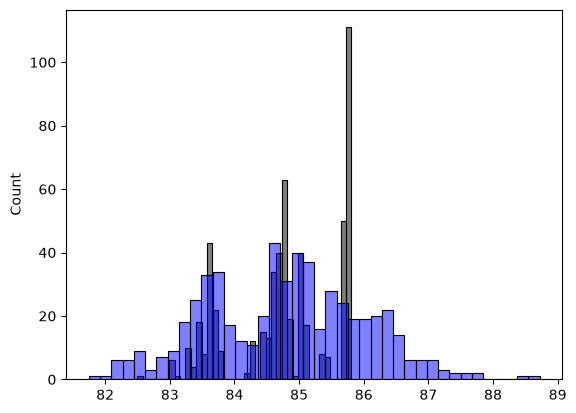

In [47]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 40) #preto = previsões
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 40) #Azul = variáveis alvo

## Avaliação do modelo de regressão (erro quadrático médio -> RMSE)

$$RMSE = \sqrt{\frac{1}{m} \sum \left( g(x_i)_{\text{previsão para } x_i} - y_{i\,\text{valor real}} \right)^2}$$

Decompondo:

$$(g(x_i) - y_i)^2 \rightarrow \text{diferença entre a previsão e o valor real, o quadrado pune os erros maiores}$$

Isso apresentado acima é o erro quadrático, agora calculamos a média e a raiz de $\frac{1}{m}$.

In [49]:
def rmse(y, y_pred):
    se = (y - y_pred) **2
    mse = se.mean()
    
    return np.sqrt(mse) 

In [50]:
rmse(y_train, y_pred) 

np.float64(0.8999730784844006)

Esse valor mostrou que o modelo aprendeu 0.82 contra um baseline de 1,24 (desvio do dado limpo completo; o da validação é 1,258 e o do teste 1,299), ≈ 56% da variância explicada com 2 colunas.

O 0.8999 acima é o erro no TREINO, medido nos mesmos dados em que os pesos foram ajustados, por isso otimista.

O 0.82 é o da validação, que aparece logo abaixo, e é ele que mede generalização.

In [51]:
base_features = ['lapnumber', 'tyrelife']   # freshtyre saiu: quase-colinear com os dummies de piloto


def prepare_X(
    df: pd.DataFrame,
    categorical_to_encode: dict[str, list],
    interactions: list[tuple[str, str]] = (),
    numericas: list[str] | None = None,
) -> tuple[np.ndarray, list[str]]:
    df = df.copy()
    features = (numericas if numericas is not None else base_features).copy()

    for column, values in categorical_to_encode.items():
        for value in values:
            feature_name = f"{column}_{value}"

            df[feature_name] = (
                df[column] == value
            ).astype(int)

            features.append(feature_name)

    for a, b in interactions:
        feature_name = f"{a}_x_{b}"

        df[feature_name] = df[a] * df[b]

        features.append(feature_name)

    df_num = df[features]

    # nao mascarar nulo com 0: tyrelife=0 ou lapnumber=0 seria uma afirmacao falsa.
    # se aparecer nulo eu quero saber, nao preencher escondido.
    assert not df_num.isnull().any().any(), 'nulo nas features: ' + str(
        df_num.columns[df_num.isnull().any()].tolist())

    return df_num.values.astype(float), features

In [52]:
X_train, _ = prepare_X(df_train, {}) 
w0, w = train_linear_regression(X_train, y_train)

X_val, _ = prepare_X(df_val, {})
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.820123321023398)

<Axes: ylabel='Count'>

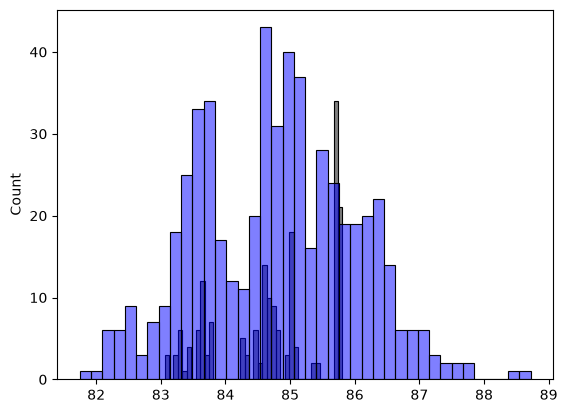

In [53]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 40) #preto = previsões
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 40) #Azul = variáveis alvo

Aqui a validação foi melhor que o treino, por causa do ruído amostral, temos 184 voltas.

Com essas voltas aquele subconjunto caiu com voltas um pouco mais previsíveis.

In [55]:
w

array([-0.06500663,  0.06224527])

Esse resultado '-0.06500663' quer dizer que a cada volta o carro fica -0.0650 mais rápido + evolução da pista.

O pneu vai soltando borracha ao longo da pista, gerando mais aderência a cada volta.

Ou seja isso é o tanque do carro esvaziando, carro fica leve e anda mais rápido

E o resultado '0.06224527' quer dizer que a cada volta do pneu o carro fica +0.062 mais lento

O modelo separou os dois pelas descontinuidades. As paradas são a fonte de identificação

Dentro de um stint de pneu esses números avançam juntos, a correlação deles é exatamente 1,0(em um stint)

Então o efeito líquido de andar mais uma volta é -0,0650 + 0,0622 = -0,0028 p/volta

Praticamente zero, dois efeitos físicos grande de sinais opostos e magnitudes quase idênticas

Antes quase descartei a feature pela correlação marginal de -0,034, era quase zero pq o pneu importa tanto como o combustível nessa pista de monza

Se eu descartassse era 0,062 s/volta em 20 voltas de stint, mais de um segundo de degradação invisível no modelo.

## Interpretando coeficientes

In [57]:
def train_with_se(X, y):
    X1 = np.column_stack([np.ones(X.shape[0]), X])

    XTX_inv = np.linalg.inv(X1.T @ X1)
    w_full  = XTX_inv @ X1.T @ y

    resid  = y - X1 @ w_full
    dof    = X1.shape[0] - X1.shape[1]     # n - p, p inclui o intercepto
    sigma2 = (resid ** 2).sum() / dof
    se     = np.sqrt(np.diag(sigma2 * XTX_inv))

    return w_full[0], w_full[1:], se[1:]


In [58]:
driver_ref, compound_ref = 'lec', 'hard'
categorical_to_encode = {
    'driver':   [d for d in sorted(df_train['driver'].unique())   if d != driver_ref],
    'compound': [c for c in sorted(df_train['compound'].unique()) if c != compound_ref],
}

X_train, names = prepare_X(df_train, categorical_to_encode)
X_val,   _     = prepare_X(df_val,   categorical_to_encode)

w0, w, se = train_with_se(X_train, y_train)

coefs = pd.DataFrame({'feature': names, 'coef': w, 'se': se})
coefs['ic95_lo'] = coefs.coef - 1.96 * coefs.se
coefs['ic95_hi'] = coefs.coef + 1.96 * coefs.se

# verifica se a coluna é mesmo o que o nome diz
assert len(names) == X_train.shape[1]
j = names.index('driver_ver')
assert (X_train[:, j] == (df_train.driver == 'ver').astype(float).values).all()

print(rmse(y_val, w0 + X_val.dot(w)))
coefs.round(4)


0.5312945805068389


,feature,coef,se,ic95_lo,ic95_hi
0,lapnumber,-0.0578,0.0020,-0.0618,-0.0538
1,tyrelife,0.0450,0.0040,0.0372,0.0529
2,driver_alb,1.2511,0.1499,0.9572,1.5449
3,driver_alo,1.1312,0.1507,0.8357,1.4266
4,driver_bot,2.0043,0.1563,1.6978,2.3107
5,driver_col,1.4642,0.1460,1.1780,1.7505
6,driver_gas,1.6593,0.1497,1.3659,1.9526
7,driver_ham,0.3072,0.1485,0.0162,0.5982
8,driver_hul,1.4455,0.1489,1.1536,1.7374
9,driver_mag,1.1042,0.1428,0.8244,1.3841


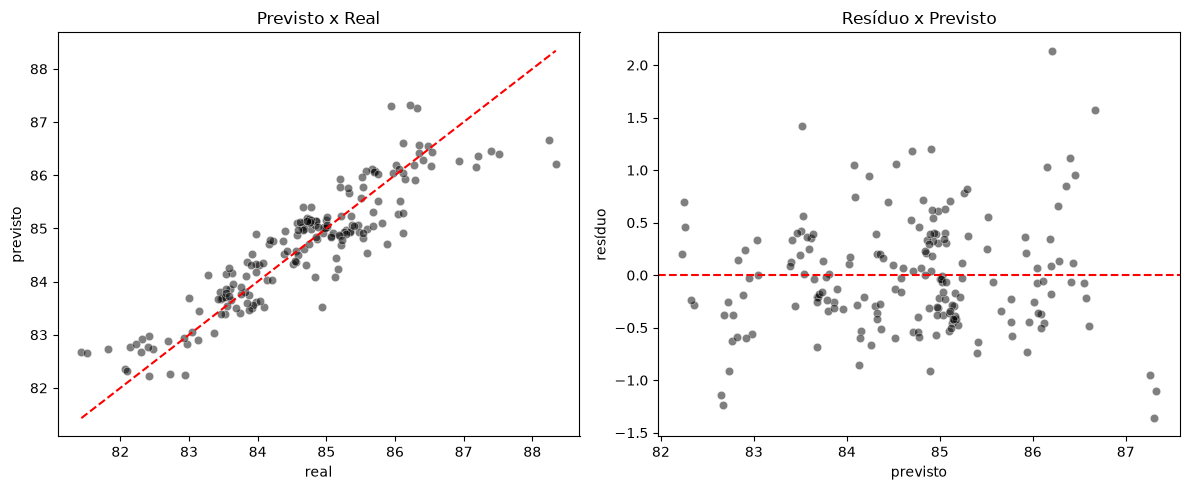

In [59]:
y_pred_val = w0 + X_val.dot(w)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) previsto x real
sns.scatterplot(x=y_val, y=y_pred_val, color='black', alpha=0.5, ax=axes[0])
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
axes[0].plot(lims, lims, color='red', linestyle='--')
axes[0].set_xlabel('real')
axes[0].set_ylabel('previsto')
axes[0].set_title('Previsto x Real')

# 2) resíduo x previsto
residuos = y_val - y_pred_val
sns.scatterplot(x=y_pred_val, y=residuos, color='black', alpha=0.5, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('previsto')
axes[1].set_ylabel('resíduo')
axes[1].set_title('Resíduo x Previsto')

plt.tight_layout()


Os pontos conseguem acompanhar a diagonal com uma certa dispersão razoável, coerente com a correlação de 0,906.

É perceptível também que o desvio em voltas rápidas é menor do que em voltas lentas.

Isso ocorre, porque voltas rápidas costumam ser mais bem feitas, são voltas limpas e portanto previsíveis.

Voltas lentas, podem ser lentas por diversos motivos, por isso são difíceis de prever.

In [61]:
pace = coefs[coefs.feature.str.startswith('driver_')].copy()
pace['driver'] = pace.feature.str.removeprefix('driver_')

ref = pd.DataFrame([{'driver': driver_ref, 'coef': 0.0, 'se': 0.0,
                     'ic95_lo': 0.0, 'ic95_hi': 0.0}])

pace = (pd.concat([ref, pace], ignore_index=True)
          .sort_values('coef')
          .reset_index(drop=True))

pace[['driver', 'coef', 'se', 'ic95_lo', 'ic95_hi']].round(3)


,driver,coef,se,ic95_lo,ic95_hi
0,pia,-0.098,0.154,-0.400,0.204
1,lec,0.000,0.000,0.000,0.000
2,nor,0.103,0.149,-0.189,0.395
3,sai,0.299,0.142,0.021,0.578
4,ham,0.307,0.148,0.016,0.598
5,rus,0.364,0.151,0.068,0.660
6,ver,0.471,0.153,0.171,0.771
7,per,0.866,0.149,0.573,1.158
8,mag,1.104,0.143,0.824,1.384
9,alo,1.131,0.151,0.836,1.427


Esperava que remover mudasse os outros coeficientes; medi e não mudou nada. O motivo é que uma dummy com uma única observação absorve só o próprio resíduo. Mantive a linha no dado: o coeficiente fica no modelo absorvendo o próprio resíduo, sem afetar o resto. Mas ele não é estimativa, é memorização de um ponto, e por isso não deve ser lido como resultado.

In [63]:
inter = [('tyrelife', 'compound_medium')]


X_train_i, names_i = prepare_X(df_train, categorical_to_encode, inter)
X_val_i,   _       = prepare_X(df_val,   categorical_to_encode, inter)

w0_i, w_i, se_i = train_with_se(X_train_i, y_train)

coefs_i = pd.DataFrame({'feature': names_i, 'coef': w_i, 'se': se_i})

k = names_i.index('tyrelife_x_compound_medium')
assert (X_train_i[:, k] ==
        (df_train.tyrelife * (df_train.compound == 'medium')).values).all()

print('rmse val:', rmse(y_val, w0_i + X_val_i.dot(w_i)).round(4))

w_tyre = coefs_i.loc[coefs_i.feature == 'tyrelife', 'coef'].iloc[0]
w_P    = coefs_i.loc[coefs_i.feature == 'tyrelife_x_compound_medium', 'coef'].iloc[0]
se_P   = coefs_i.loc[coefs_i.feature == 'tyrelife_x_compound_medium', 'se'].iloc[0]

print(f'hard:   {w_tyre:.4f} s/volta')
print(f'medium: {w_tyre + w_P:.4f} s/volta')
print(f'w_P:    {w_P:+.4f} +- {se_P:.4f} '
      f'(IC95 {w_P - 1.96*se_P:+.4f} a {w_P + 1.96*se_P:+.4f})')

print(df_train.groupby('compound').tyrelife.agg(['size', 'min', 'max', 'mean']).round(1))

coefs_i[~coefs_i.feature.str.startswith('driver_')].round(4)

rmse val: 0.5308
hard:   0.0463 s/volta
medium: 0.0258 s/volta
w_P:    -0.0205 +- 0.0110 (IC95 -0.0421 a +0.0011)
          size  min   max  mean
compound                       
hard       408  2.0  41.0  14.3
medium     145  2.0  21.0   8.7
soft         1  2.0   2.0   2.0


,feature,coef,se
0,lapnumber,-0.0572,0.0021
1,tyrelife,0.0463,0.0041
20,compound_medium,0.4825,0.1164
21,compound_soft,-1.0386,0.5814
22,tyrelife_x_compound_medium,-0.0205,0.0110


## Observações

Primeiro previ que o médio degradaria mais rápido

Resultado me contradisse, deu hard 0,046 vs medium 0,026, mas olhando o intervalo de confiança do coeficiente, percebemos que ele cruza o zero, então os dados não sustentam que as taxas sejam diferentes

Nenhum stint de pneu médio passou de 21 voltas, o duro chegou a 43. O médio degrada mais rápido, mecânicos trocam o pneu e recolhem, o duro aguenta e fica na pista

Ou seja o médio é observado só na fase inicial da vida dele, onde tem pouca degradação, o duro é observado até o fim.

Se ajustarmos uma reta para cada um, a do médio vai pegar o trecho mais suave e sai mais plana, pesquisei e achei um nome para isso.

Viés de seleção por truncamento, onde a regra que decide quando parar de observar depende da própria variável medida.

Quando suspeitei que tinha dado ruim, o instinto tava certo, mas a pergunta "qual composto degrada mais rápido", não é respondível com os dados de apenas uma corrida(projeto futuro)

Vamos medir o quanto o corte aleatório inflou o RMSE

Voltas seguidas do mesmo piloto são quase idênticas, então embaralhar coloca gêmeas dos dois lados do corte

In [66]:
corte = df_clean_monza  #dado sem embaralhamento


def ajusta_corte(tr, va):
    """treina em tr, preve em va. dropa coluna constante no treino, senao a matriz fica singular."""
    cte = {'driver':   [x for x in sorted(tr.driver.unique())   if x != driver_ref],
           'compound': [x for x in sorted(tr.compound.unique()) if x != compound_ref]}

    Xt, _ = prepare_X(tr, cte)
    Xv, _ = prepare_X(va, cte)

    manter = Xt.std(axis=0) > 0
    Xt, Xv = Xt[:, manter], Xv[:, manter]

    X1 = np.column_stack([np.ones(len(Xt)), Xt])
    w  = np.linalg.lstsq(X1, tr.laptime.values, rcond=None)[0] 

    return w[0] + Xv @ w[1:]


cum = corte.lapnumber.value_counts().sort_index().cumsum() / len(corte)
L   = int(cum[cum >= 0.6].index[0])    

tr_t = corte[corte.lapnumber <= L]
va_t = corte[corte.lapnumber >  L]

res = va_t.laptime.values - ajusta_corte(tr_t, va_t)

print(f'corte na volta {L}    treino={len(tr_t)}  validacao={len(va_t)}')
print(f'rmse       {np.sqrt((res ** 2).mean()):.4f}')
print(f'vies       {res.mean():+.3f}')
print(f'dispersao  {res.std():.4f}')

faixa = pd.cut(va_t.lapnumber, [L, 38, 43, 48, 53])
print(va_t.assign(res=res).groupby(faixa, observed=True).res.agg(
    n='size', vies='mean', se=lambda x: x.std() / np.sqrt(len(x))).round(3))

corte na volta 33    treino=564  validacao=358
rmse       0.7681
vies       +0.319
dispersao  0.6988
            n   vies     se
lapnumber                  
(33, 38]   84  0.334  0.081
(38, 43]   92  0.420  0.061
(43, 48]   95  0.337  0.073
(48, 53]   87  0.178  0.080


In [67]:
def rmse_corte(tr, va):
    return np.sqrt(((va.laptime.values - ajusta_corte(tr, va)) ** 2).mean())


bl = corte.driver.astype(str) + '_' + corte.stint.astype(str)
aleat, bloco = [], []

for s in range(200):
    rng = np.random.default_rng(s)

    i = rng.permutation(len(corte)); k = int(len(corte) * 0.6)
    aleat.append(rmse_corte(corte.iloc[i[:k]], corte.iloc[i[k:]]))

    fora = [f'{drv}_{rng.choice(sorted(g.stint.unique()))}' for drv, g in corte.groupby('driver')]
    bloco.append(rmse_corte(corte[~bl.isin(fora)], corte[bl.isin(fora)]))

aleat, bloco = np.array(aleat), np.array(bloco)

print(f'baseline (desvio de laptime)  {corte.laptime.std():.4f}')
print(f'aleatorio 60/40    {aleat.mean():.4f} +- {aleat.std():.4f}')
print(f'bloco de stint     {bloco.mean():.4f} +- {bloco.std():.4f}')
print(f'temporal (volta {L})  {np.sqrt((res ** 2).mean()):.4f}')

baseline (desvio de laptime)  1.2392
aleatorio 60/40    0.5716 +- 0.0276
bloco de stint     0.5931 +- 0.0337
temporal (volta 33)  0.7681


In [68]:
from sklearn.linear_model import LinearRegression

modelo_skl = LinearRegression().fit(X_train, y_train)

print('intercepto  meu: %.10f' % w0)
print('intercepto skl: %.10f' % modelo_skl.intercept_)
print()
print('|dif| max intercepto :', abs(w0 - modelo_skl.intercept_))
print('|dif| max nos pesos  :', np.abs(w - modelo_skl.coef_).max())
print('np.allclose          :', np.allclose(w, modelo_skl.coef_))
print()
print('RMSE meu : %.10f' % rmse(y_val, w0 + X_val.dot(w))) #Eu fazendo regressão na mão
print('RMSE skl : %.10f' % rmse(y_val, modelo_skl.predict(X_val))) #Biblioteca Sklearn

intercepto  meu: 84.6841704870
intercepto skl: 84.6841704870

|dif| max intercepto : 6.963318810448982e-13
|dif| max nos pesos  : 8.211209490127658e-13
np.allclose          : True

RMSE meu : 0.5312945805
RMSE skl : 0.5312945805


Aqui deu pra confirmar que consegui montar a regressão do zero corretamente.

Construi dessa forma, pois acredito que assim é melhor para o entendimento, vendo realmente como funciona.

Pensando e criando as coisas do zero assim, é o diferencial de pensamento para realmente construir e modelar mais coisas do zero.

O maior foco esta em ver como realmente funciona, ver que não é mágica, para poder criar o mesmo tipo de 'mágica' de forma autoral

## Usando conjunto de teste

In [ ]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop = True)

In [ ]:
y_full_train = np.concatenate([y_train, y_val])   # mesma ordem do concat acima

In [ ]:
len(df_full_train) == len(y_full_train)   # alinhamento

In [81]:
categorical_full = {
    'driver':   [d for d in sorted(df_full_train['driver'].unique())   if d != driver_ref],
    'compound': [c for c in sorted(df_full_train['compound'].unique()) if c != compound_ref],
}

In [ ]:
# se um nivel aparecer so no teste, prepare_X nao cria a coluna e a linha entra
# como se fosse a referencia, silenciosamente. melhor quebrar do que errar calado.
for _col in categorical_full:
    _falta = set(df_test[_col].unique()) - set(df_full_train[_col].unique())
    assert not _falta, f'{_col}: nivel so no teste -> {_falta}'
print('ok: todos os niveis do teste existem no treino')

In [82]:
X_full_train, names_full = prepare_X(df_full_train, categorical_full)
X_test,       _          = prepare_X(df_test,       categorical_full)

In [83]:
w0_f, w_f = train_linear_regression(X_full_train, y_full_train)

In [84]:
y_pred_test = w0_f + X_test.dot(w_f)

In [87]:
print('RMSE teste :', rmse(y_test, y_pred_test))

RMSE teste : 0.5870036908121713


Resultado esperado 10% pior que a validação, pois naturalmente o teste é um conjunto mais difícil, o teste tem alvo mais disperso.

Nele ficou a volta do zhou que eu tinha observado no começo do projeto, a volta mais lenta da corrida com 89,26s.

Mais dispersão significa mais coisa para explicar, RMSE tende a ser maior com o mesmo modelo.

Com esse RMSE primeiro eu suspeitei do composto, mas além de verificar, lembrei que havia apenas uma de macio que é o que daria maior diferença.

A diferença vem da dispersão do próprio conjunto.

## O resíduo tem curvatura em `tyrelife`?

O gráfico de resíduo contra previsto mostra se o erro cresce com o tamanho da previsão. Ele não responde se falta **curvatura** numa feature específica. Para isso o resíduo tem que ser plotado contra a própria feature: se a degradação do pneu não for linear, o resíduo contra `tyrelife` mostra formato de U.

In [ ]:
residuos_val = y_val - y_pred_val

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(x=df_val.tyrelife, y=residuos_val, color='black', alpha=0.45, ax=ax)

# media do residuo por faixa de tyrelife, pra enxergar padrao no meio da nuvem
faixas = pd.cut(df_val.tyrelife, [0, 5, 10, 15, 20, 25, 45])
medias = pd.DataFrame({'res': residuos_val, 'faixa': faixas}).groupby('faixa', observed=True).res.mean()
centros = [iv.mid for iv in medias.index]
ax.plot(centros, medias.values, color='red', marker='o', lw=2, label='média por faixa')

ax.axhline(0, color='red', ls='--', lw=1)
ax.set_xlabel('tyrelife'); ax.set_ylabel('resíduo'); ax.legend(frameon=False)
plt.tight_layout()

In [ ]:
# agora sem mutar global: prepare_X aceita a lista de numericas
def com_quadratico(df, cat):
    df = df.copy()
    df['tyrelife2'] = df.tyrelife ** 2
    return prepare_X(df, cat, numericas=['lapnumber', 'tyrelife', 'tyrelife2'])


X_train_q, nomes_q = com_quadratico(df_train, categorical_to_encode)
X_val_q,   _       = com_quadratico(df_val,   categorical_to_encode)

w0_q, w_q, se_q = train_with_se(X_train_q, y_train)

j = nomes_q.index('tyrelife2')
print('coef tyrelife^2 = %+.5f ± %.5f  (IC95 %+.5f a %+.5f)'
      % (w_q[j], se_q[j], w_q[j] - 1.96*se_q[j], w_q[j] + 1.96*se_q[j]))
print()
print('num split unico:')
print('  sem quadrático  RMSE val %.4f' % rmse(y_val, w0 + X_val.dot(w)))
print('  com quadrático  RMSE val %.4f' % rmse(y_val, w0_q + X_val_q.dot(w_q)))

O coeficiente é estatisticamente detectável, o intervalo não cruza o zero. Mas a diferença de RMSE num split único é de milésimos, e o desvio entre seeds que eu medi na comparação de cortes foi de 0,028, vinte vezes maior. Então esse número sozinho não decide nada, é ruído.

Repetindo com 200 seeds, comparação pareada (mesma seed nos dois modelos):

```
sem tyrelife²      0,5716 ± 0,0276
com tyrelife²      0,5717 ± 0,0273
diferença          +0,0002 ± 0,0020
melhorou em        125 de 200 seeds
```

A diferença é indistinguível de zero, e o quadrático melhora em pouco mais da metade das seeds, o que é o que se espera de duas coisas equivalentes. A afirmação defensável não é "piorou", é **não melhorou**.

Ou seja: existe curvatura mensurável na degradação, e ela não ajuda a prever. Coerente com o truncamento que apareceu na análise por composto, a curvatura vem dos poucos stints muito longos, e a estratégia impede que o pneu chegue lá com frequência.

Fica de fora pelo mesmo critério das outras features: não pagou o grau de liberdade.

---

## Próximos passos

**Expandir para a temporada inteira.** O `voltas_f1.parquet` já tem as 24 corridas de 2024, então o pipeline não muda, só o recorte. Isso resolve de uma vez as três limitações que apareceram aqui:

- **Norris x Piastri deixa de ser indistinguível.** Com uma corrida a margem ficou em ±0,29 s/volta, e a diferença real entre companheiros de equipe é da ordem de 0,1 a 0,3. O erro-padrão cai com $\sqrt{n}$, então mais corridas estreitam o intervalo até a diferença aparecer, se ela existir.
- **A degradação por composto passa a ser respondível.** Aqui o medium só foi observado até 21 voltas porque a estratégia recolhe o pneu quando ele degrada, o truncamento por seleção. Com 24 corridas há estratégias diferentes, stints de durações variadas, e o trecho final da vida do medium aparece em algum lugar.
- **`evento` vira feature.** Deixa de ser coluna constante e passa a medir o efeito da pista, o que também permite testar se o ritmo relativo dos pilotos muda de circuito para circuito.

**Comparar com outra classe de modelo.** Só usei regressão linear. Um modelo de árvore responderia quanto custa a suposição de linearidade, e se o RMSE de 0,587 é limite do problema ou limite do modelo.

**Corrigir os intervalos de confiança.** Os erros-padrão aqui supõem erros independentes e variância constante, e eu mostrei que nenhuma das duas vale: voltas do mesmo piloto são correlacionadas e o desvio é maior nas voltas lentas. Os intervalos estão otimistas.